### From 11 classes → 5 classes:

clothes, glass, metal, paper, plastic

And apply that to:

train
val
test

In [1]:
import shutil
from pathlib import Path

# ============================================================
# CONFIGURATION
# ============================================================

ORIGINAL_DATASET = Path("D:/ImgProject/split_dataset")
NEW_DATASET      = Path("D:/ImgProject/filtered_dataset")

TARGET_CLASSES = [
    "glass",
    "clothes",
    "metal",
    "paper",
    "plastic"
]

SPLITS = ["train", "val", "test"]

In [2]:
# ============================================================
# FUNCTION — FILTER DATASET
# ============================================================

def create_filtered_dataset():
    print("=" * 55)
    print("Creating Filtered Dataset (5 Classes)")
    print("=" * 55)

    # Remove old filtered dataset if exists
    if NEW_DATASET.exists():
        print("Removing existing filtered dataset...")
        shutil.rmtree(NEW_DATASET)

    for split in SPLITS:
        for cls in TARGET_CLASSES:

            src_dir = ORIGINAL_DATASET / split / cls
            dst_dir = NEW_DATASET / split / cls

            if not src_dir.exists():
                print(f"⚠️ Missing: {src_dir}")
                continue

            # Create destination folder
            dst_dir.mkdir(parents=True, exist_ok=True)

            images = list(src_dir.glob("*"))
            print(f"{split}/{cls}: {len(images)} images")

            for img_path in images:
                shutil.copy(img_path, dst_dir / img_path.name)

    print("\n✅ Filtered dataset created successfully!")
    print(f"Location: {NEW_DATASET}")

In [3]:
# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    create_filtered_dataset()

Creating Filtered Dataset (5 Classes)
train/glass: 720 images
train/clothes: 720 images
train/metal: 720 images
train/paper: 720 images
train/plastic: 720 images
val/glass: 90 images
val/clothes: 90 images
val/metal: 90 images
val/paper: 90 images
val/plastic: 90 images
test/glass: 90 images
test/clothes: 90 images
test/metal: 90 images
test/paper: 90 images
test/plastic: 90 images

✅ Filtered dataset created successfully!
Location: D:\ImgProject\filtered_dataset


In [2]:
# ============================================================
# PREPROCESSING PIPELINE — Garbage Classification
# Smart Garbage Classification Project
# 11 Classes | ~9,891 Images | Split: 80/10/10
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# ============================================================
# CONFIGURATION (UPDATED)
# ============================================================

DATASET_PATH = "D:/ImgProject/filtered_dataset"
IMG_SIZE      = (128, 128)   # reduced from 224
BATCH_SIZE    = 32
NUM_CLASSES   = 5

CLASSES = [
    'clothes', 'glass', 'metal', 'paper', 'plastic'
]


# ============================================================
# STEP 1 — HANDLE CORRUPTED / UNREADABLE IMAGES
# This is required by the guidelines
# ============================================================

def check_and_remove_corrupted(dataset_path):
    """
    Scan all images in train/val/test folders.
    Remove any file that OpenCV cannot read (corrupted).
    """
    dataset_path = Path(dataset_path)
    total_checked = 0
    total_removed = 0

    print("=" * 55)
    print("STEP 1 — Checking for Corrupted Images")
    print("=" * 55)

    for split in ["train", "val", "test"]:
        for class_name in CLASSES:
            folder = dataset_path / split / class_name

            if not folder.exists():
                continue

            for img_file in folder.iterdir():
                if img_file.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]:
                    continue

                total_checked += 1
                img = cv2.imread(str(img_file))

                if img is None:
                    print(f"  ✗ Corrupted → removed: {img_file.name}")
                    img_file.unlink()
                    total_removed += 1

    print(f"\n  Total images checked : {total_checked}")
    print(f"  Corrupted & removed  : {total_removed}")
    print(f"  Clean images         : {total_checked - total_removed}")
    print()
    
    
# ============================================================
# STEP 2 — CLASS BALANCE CHECK
# Required by the guidelines: check imbalance & document it
# ============================================================

def check_class_balance(dataset_path, split="train"):
    """
    Count images per class in the given split.
    Plot a bar chart showing class distribution.
    """
    dataset_path = Path(dataset_path)
    counts = {}

    print("=" * 55)
    print(f"STEP 2 — Class Balance Check ({split} set)")
    print("=" * 55)

    for class_name in CLASSES:
        folder = dataset_path / split / class_name
        if folder.exists():
            count = len([
                f for f in folder.iterdir()
                if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
            ])
            counts[class_name] = count
            print(f"  {class_name:<12} : {count} images")
        else:
            counts[class_name] = 0
            print(f"  {class_name:<12} : folder not found")

    total = sum(counts.values())
    print(f"\n  Total ({split}) : {total} images")

    # ── visualise ──────────────────────────────────────────
    plt.figure(figsize=(12, 5))
    bars = plt.bar(counts.keys(), counts.values(),
                   color='steelblue', edgecolor='black')
    plt.title(f"Class Distribution — {split.capitalize()} Set",
              fontsize=14, fontweight='bold')
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha='right')

    for bar, val in zip(bars, counts.values()):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"class_distribution_{split}.png", dpi=150)
    plt.show()
    print(f"\n  Chart saved → class_distribution_{split}.png\n")

    return counts


# ============================================================
# STEP 3 — SAMPLE IMAGES GRID
# Show one sample from each class before augmentation
# ============================================================

def show_sample_images(dataset_path, split="train", n_per_row=4):
    """
    Display one sample image per class in a grid.
    """
    dataset_path = Path(dataset_path)
    images, labels = [], []

    for class_name in CLASSES:
        folder = dataset_path / split / class_name
        if not folder.exists():
            continue
        files = list(folder.iterdir())
        if files:
            img = cv2.imread(str(files[0]))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(class_name)

    rows = (len(images) + n_per_row - 1) // n_per_row
    fig, axes = plt.subplots(rows, n_per_row,
                              figsize=(n_per_row * 3, rows * 3))
    axes = axes.flatten()

    for i, (img, label) in enumerate(zip(images, labels)):
        axes[i].imshow(img)
        axes[i].set_title(label, fontsize=10, fontweight='bold')
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Sample Images — One Per Class (Resized 128×128)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("sample_images_grid.png", dpi=150)
    plt.show()
    print("  Sample grid saved → sample_images_grid.png\n")

In [3]:
# ============================================================
# STEP 4 — DATA AUGMENTATION + NORMALIZATION
# Exactly as required by the guidelines:
#   • Resize 128×128
#   • Normalize [0,1]
#   • Rotation, Flip, Zoom, Brightness
#   • Train / Val / Test split already done on disk
# ============================================================

def build_data_generators(dataset_path):
    """
    Build ImageDataGenerators for train, val, and test splits.
    Train → augmentation + normalization
    Val/Test → normalization only (no augmentation on evaluation data)
    """

    # ── TRAIN: stronger augmentation ───────────────────────────────
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,          # Normalize [0, 1]
        
        rotation_range=25,          # Random rotation ±25°
        zoom_range=0.25,             # Random zoom 25%
        horizontal_flip=True,       # Random horizontal flip
        
        width_shift_range=0.1,     #  NEW
        height_shift_range=0.1,    #  NEW
        shear_range=0.1,           #  NEW
        
        brightness_range=[0.7, 1.3] # Random brightness adjustment
    )

    # ── VAL & TEST: normalization only ────────────────────
    val_test_datagen = ImageDataGenerator(
        rescale=1.0 / 255           # Normalize [0, 1] only
    )

    # ── LOAD from directory ───────────────────────────────
    train_data = train_datagen.flow_from_directory(
        os.path.join(dataset_path, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',   # one-hot labels for 5 classes
        shuffle=True
    )

    val_data = val_test_datagen.flow_from_directory(
        os.path.join(dataset_path, "val"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False               # keep order for evaluation
    )

    test_data = val_test_datagen.flow_from_directory(
        os.path.join(dataset_path, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    return train_data, val_data, test_data


# ============================================================
# STEP 5 — VISUALISE AUGMENTED SAMPLES
# Show what the model actually sees after augmentation
# ============================================================

def show_augmented_samples(train_data, n=8):
    """
    Fetch one batch and display n augmented images.
    """
    images, labels = next(train_data)
    class_names = list(train_data.class_indices.keys())

    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 5))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(images[i])
        label_idx = np.argmax(labels[i])
        axes[i].set_title(class_names[label_idx], fontsize=9)
        axes[i].axis('off')

    plt.suptitle("Augmented Training Samples (Normalized [0,1])",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("augmented_samples.png", dpi=150)
    plt.show()
    print("  Augmented samples saved → augmented_samples.png\n")
    
    
# ============================================================
# STEP 6 — PRINT PREPROCESSING SUMMARY
# ============================================================

def print_preprocessing_summary(train_data, val_data, test_data):
    print("\n" + "=" * 55)
    print("PREPROCESSING SUMMARY")
    print("=" * 55)
    print(f"  Image Size         : {IMG_SIZE[0]} × {IMG_SIZE[1]} (RGB)")
    print(f"  Normalization      : Pixel values scaled to [0, 1]")
    print(f"  Batch Size         : {BATCH_SIZE}")
    print(f"  Number of Classes  : {NUM_CLASSES}")
    print()
    print(f"  Train samples      : {train_data.samples}")
    print(f"  Val   samples      : {val_data.samples}")
    print(f"  Test  samples      : {test_data.samples}")
    print()
    print("  Train Augmentation :")
    print("    ✓ Rotation  ±25°")
    print("    ✓ Zoom       25%")
    print("    ✓ Horizontal Flip")
    print("    ✓ Brightness [0.7 – 1.3]")
    print()
    print("  Val/Test: No augmentation (normalization only)")
    print("=" * 55)
    print()


   GARBAGE CLASSIFICATION — PREPROCESSING PIPELINE

STEP 1 — Checking for Corrupted Images

  Total images checked : 4500
  Corrupted & removed  : 0
  Clean images         : 4500

STEP 2 — Class Balance Check (train set)
  clothes      : 720 images
  glass        : 720 images
  metal        : 720 images
  paper        : 720 images
  plastic      : 720 images

  Total (train) : 3600 images


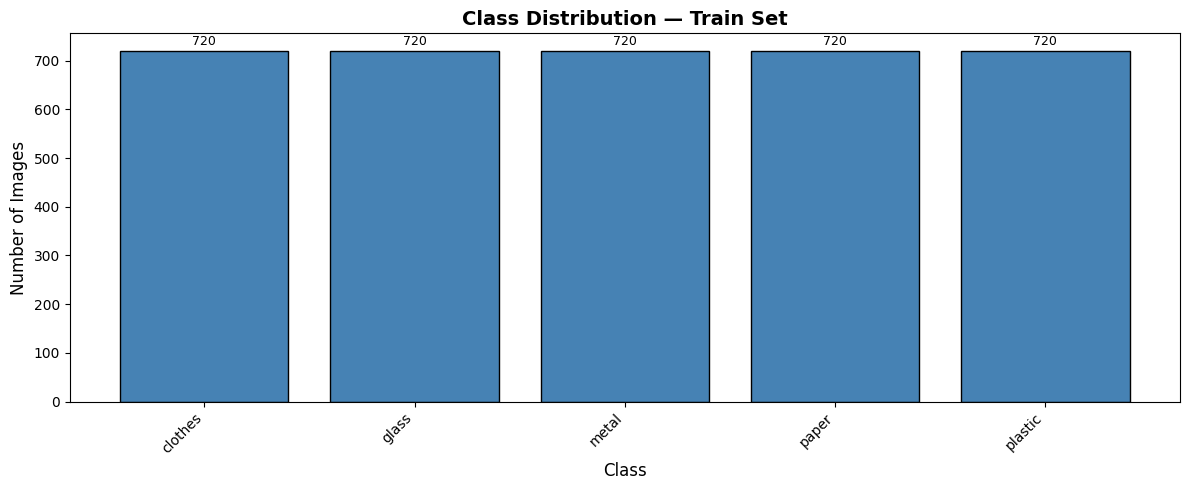


  Chart saved → class_distribution_train.png



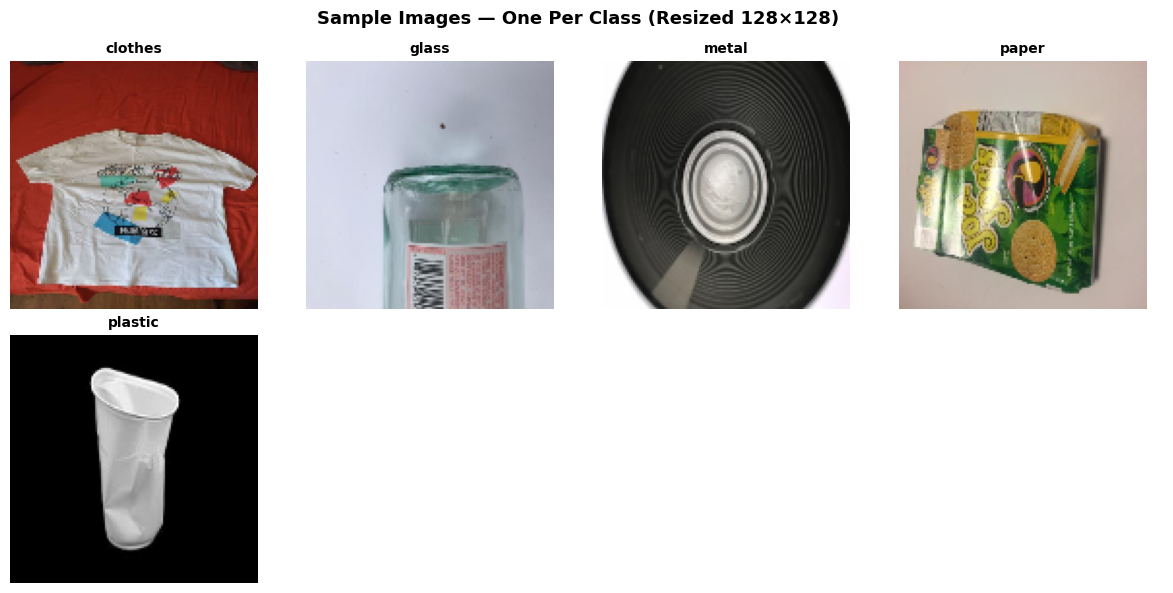

  Sample grid saved → sample_images_grid.png

Found 3600 images belonging to 5 classes.
Found 450 images belonging to 5 classes.
Found 450 images belonging to 5 classes.


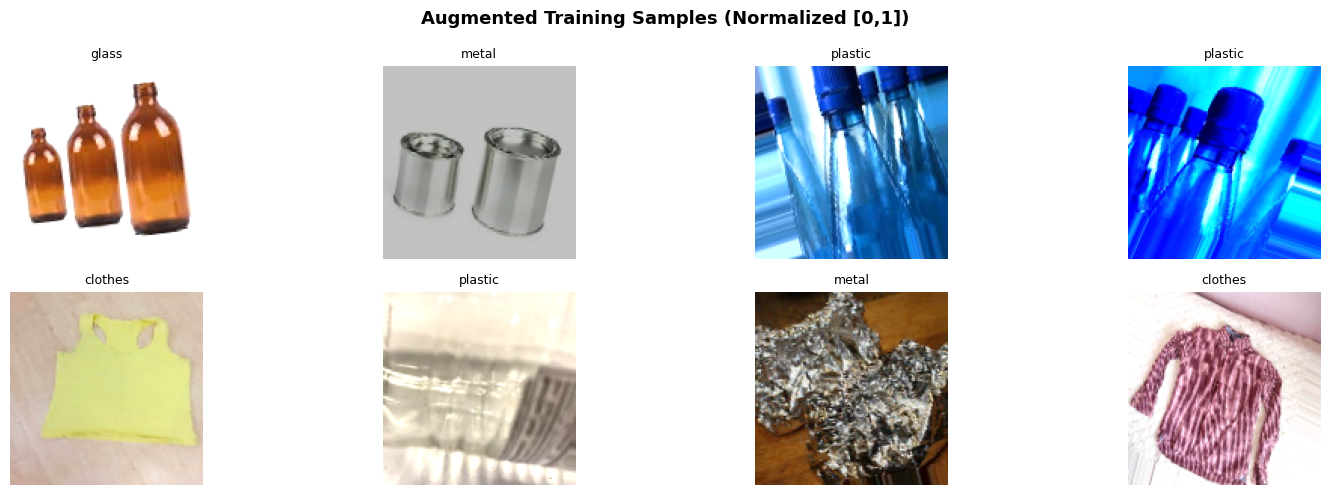

  Augmented samples saved → augmented_samples.png


PREPROCESSING SUMMARY
  Image Size         : 128 × 128 (RGB)
  Normalization      : Pixel values scaled to [0, 1]
  Batch Size         : 32
  Number of Classes  : 5

  Train samples      : 3600
  Val   samples      : 450
  Test  samples      : 450

  Train Augmentation :
    ✓ Rotation  ±25°
    ✓ Zoom       25%
    ✓ Horizontal Flip
    ✓ Brightness [0.7 – 1.3]

  Val/Test: No augmentation (normalization only)

✅ Preprocessing pipeline complete.
   → train_data, val_data, test_data are ready for model training.



In [4]:
# ============================================================
# MAIN — RUN FULL PIPELINE
# ============================================================

if __name__ == "__main__":

    print("\n" + "=" * 55)
    print("   GARBAGE CLASSIFICATION — PREPROCESSING PIPELINE")
    print("=" * 55 + "\n")

    # Step 1 — Remove corrupted images
    check_and_remove_corrupted(DATASET_PATH)

    # Step 2 — Check class balance (train set)
    check_class_balance(DATASET_PATH, split="train")

    # Step 3 — Show one sample per class
    show_sample_images(DATASET_PATH, split="train")

    # Step 4 — Build data generators
    train_data, val_data, test_data = build_data_generators(DATASET_PATH)

    # Step 5 — Show augmented samples
    try:
        show_augmented_samples(train_data, n=8)
    except Exception as e:
        print("Augmentation preview skipped:", e)
        
    # Step 6 — Print summary
    print_preprocessing_summary(train_data, val_data, test_data)

    print("✅ Preprocessing pipeline complete.")
    print("   → train_data, val_data, test_data are ready for model training.\n")

In [16]:
# ============================================================
# CNN FROM SCRATCH — Garbage Classification
# Smart Garbage Classification Project
# Architecture built layer-by-layer (no pre-trained weights)
# Required by Project Guidelines Section 4.1
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D,
    Dense, Dropout, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)


# ============================================================
# CONFIGURATION
# ============================================================

NUM_CLASSES = 5
IMG_SIZE    = (128, 128)  # match preprocessing
input_shape = (128, 128, 3)
EPOCHS      = 30   # critical change (instead of 5)
BATCH_SIZE  = 32

CLASSES = [
    'clothes', 'glass', 'metal', 'paper', 'plastic'
]

In [17]:
# ============================================================
# BUILD CNN FROM SCRATCH
# Every layer explicitly defined — no drag-and-drop
# Architecture: Conv → BN → ReLU → Pool (× 3 blocks)
#               → Flatten → Dense → Dropout → Output (Softmax)
# ============================================================

def build_cnn_from_scratch(input_shape=input_shape, num_classes=NUM_CLASSES):
    """
    Full CNN architecture built from scratch.

    Block 1: 32 filters  → capture low-level features (edges, textures)
    Block 2: 64 filters  → capture mid-level features (shapes)
    Block 3: 128 filters → capture high-level features (object parts)
    Block 4: 256 filters → capture complex patterns

    Fully Connected Head:
        Flatten → Dense(512) → Dropout(0.5) → Dense(256) → Output(Softmax)
    """

    model = Sequential(name="CNN_from_Scratch_Improved")

    # ── BLOCK 1 ────────────────────────────────────────────
    # Input: 128 × 128 × 3
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())
    # Output: 112 × 112 × 32

    # ── BLOCK 2 ────────────────────────────────────────────
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())
    # Output: 56 × 56 × 64

    # ── BLOCK 3 ────────────────────────────────────────────
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())
    # Output: 28 × 28 × 128

    # ── BLOCK 4 ────────────────────────────────────────────
    model.add(Conv2D(256, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())
    # Output: 14 × 14 × 256

    # ── CLASSIFIER HEAD ────────────────────────────────────
    
    # KEY CHANGE — replace Flatten
    model.add(GlobalAveragePooling2D())
    
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.4))          # reduce overfitting

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.3))

    # Output layer — Softmax for 5-class classification
    model.add(Dense(num_classes, activation='softmax'))

    return model

In [18]:
# ============================================================
# COMPILE MODEL
# ============================================================

def compile_model(model):
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # reduced
        loss='categorical_crossentropy',     # multi-class loss
        metrics=['accuracy']
    )
    return model


# ============================================================
# CALLBACKS
# Stop early if no improvement; save best weights; reduce LR
# ============================================================

def get_callbacks(model_name="cnn_scratch_best.keras"):
    callbacks = [

        # Stop training if val_loss doesn't improve for 5 epochs
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        # Save the best model weights automatically
        ModelCheckpoint(
            filepath=model_name,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),

        # Reduce learning rate when val_loss plateaus
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]
    return callbacks

In [19]:
# ============================================================
# TRAIN MODEL
# ============================================================

def train_cnn(model, train_data, val_data, epochs=EPOCHS):
    """
    Train the CNN and record training time.
    Returns: history object + elapsed time in seconds
    """
    callbacks = get_callbacks()

    print("\n" + "=" * 55)
    print("TRAINING — CNN from Scratch")
    print("=" * 55)

    start_time = time.time()

    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=val_data,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.time() - start_time

    print(f"\n  Training completed in {elapsed:.1f} seconds "
          f"({elapsed / 60:.1f} minutes)")

    return history, elapsed


# ============================================================
# PLOT TRAINING CURVES
# Required by guidelines: Loss & Accuracy over epochs
# ============================================================

def plot_training_history(history, model_name="CNN from Scratch"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Accuracy ───────────────────────────────────────────
    axes[0].plot(history.history['accuracy'],
                 label='Train Accuracy', color='steelblue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'],
                 label='Val Accuracy', color='orange', linewidth=2)
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Loss ───────────────────────────────────────────────
    axes[1].plot(history.history['loss'],
                 label='Train Loss', color='steelblue', linewidth=2)
    axes[1].plot(history.history['val_loss'],
                 label='Val Loss', color='orange', linewidth=2)
    axes[1].set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("cnn_scratch_training_curves.png", dpi=150)
    plt.show()
    print("  Training curves saved → cnn_scratch_training_curves.png\n")


# ============================================================
# EVALUATE ON TEST SET
# Required by guidelines: Accuracy, Precision, Recall, F1, CM
# ============================================================

def evaluate_model(model, test_data):
    """
    Full evaluation on the held-out test set.
    Prints: Accuracy, Precision, Recall, F1
    Plots : Confusion Matrix heatmap
    """
    print("\n" + "=" * 55)
    print("EVALUATION — Test Set")
    print("=" * 55)

    # ── Predictions ────────────────────────────────────────
    test_data.reset()
    y_pred_prob = model.predict(test_data, verbose=1)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = test_data.classes

    # ── Metrics ────────────────────────────────────────────
    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n  Accuracy  : {acc:.4f}  ({acc * 100:.2f}%)")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    # ── Per-class Report ───────────────────────────────────
    print("\n  Per-Class Classification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # ── Confusion Matrix ───────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASSES,
        yticklabels=CLASSES
    )
    plt.title("Confusion Matrix — CNN from Scratch", fontsize=14, fontweight='bold')
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("cnn_scratch_confusion_matrix.png", dpi=150)
    plt.show()
    print("  Confusion matrix saved → cnn_scratch_confusion_matrix.png\n")

    return {
        "accuracy"  : acc,
        "precision" : precision,
        "recall"    : recall,
        "f1_score"  : f1
    }


# ============================================================
# PRINT MODEL SUMMARY (trainable params)
# ============================================================

def print_model_info(model):
    print("\n" + "=" * 55)
    print("MODEL ARCHITECTURE SUMMARY")
    print("=" * 55)
    model.summary()

    trainable_params = np.sum([
        np.prod(w.shape) for w in model.trainable_weights
    ])
    print(f"\n  Trainable Parameters : {trainable_params:,}")
    print()


  GARBAGE CLASSIFICATION — CNN from Scratch

Loading data generators...
Found 3600 images belonging to 5 classes.
Found 450 images belonging to 5 classes.
Found 450 images belonging to 5 classes.

Building CNN from scratch...

MODEL ARCHITECTURE SUMMARY


Model: "CNN_from_Scratch_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 256)                 │           1,0

 Total params: 491,205 (1.87 MB)

 Trainable params: 489,477 (1.87 MB)

 Non-trainable params: 1,728 (6.75 KB)


  Trainable Parameters : 489,477


TRAINING — CNN from Scratch
Epoch 1/30
 22/113 ━━━━━━━━━━━━━━━━━━━━ 1:43 1s/step - accuracy: 0.2895 - loss: 1.8128

C:\Users\HP\anaconda3\envs\imgcv\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3852 - loss: 1.5567
Epoch 1: val_accuracy improved from None to 0.20000, saving model to cnn_scratch_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.4319 - loss: 1.4181 - val_accuracy: 0.2000 - val_loss: 2.0097 - learning_rate: 5.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5095 - loss: 1.2560
Epoch 2: val_accuracy improved from 0.20000 to 0.32667, saving model to cnn_scratch_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5008 - loss: 1.2619 - val_accuracy: 0.3267 - val_loss: 2.1222 - learning_rate: 5.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5086 - loss: 1.2370
Epoch 3: val_accuracy did not improve from 0.32667
113/113 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.5267 - loss: 1.2070 - val_accuracy: 0.2889 - val_loss: 2.4306 - learning_rate: 5.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5585 - loss: 1.

Epoch 23/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7703 - loss: 0.6439
Epoch 23: val_accuracy did not improve from 0.78000
113/113 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7644 - loss: 0.6574 - val_accuracy: 0.7800 - val_loss: 0.6235 - learning_rate: 1.2500e-04
Epoch 24/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7437 - loss: 0.6980
Epoch 24: val_accuracy did not improve from 0.78000
113/113 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7492 - loss: 0.6817 - val_accuracy: 0.6800 - val_loss: 0.8745 - learning_rate: 1.2500e-04
Epoch 25/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7479 - loss: 0.6713
Epoch 25: val_accuracy did not improve from 0.78000

Epoch 25: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
113/113 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7469 - loss: 0.6678 - val_accuracy: 0.7111 - val_loss: 0.7283 - learning_rate: 1.2500e-04
Epoch 26/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7600 

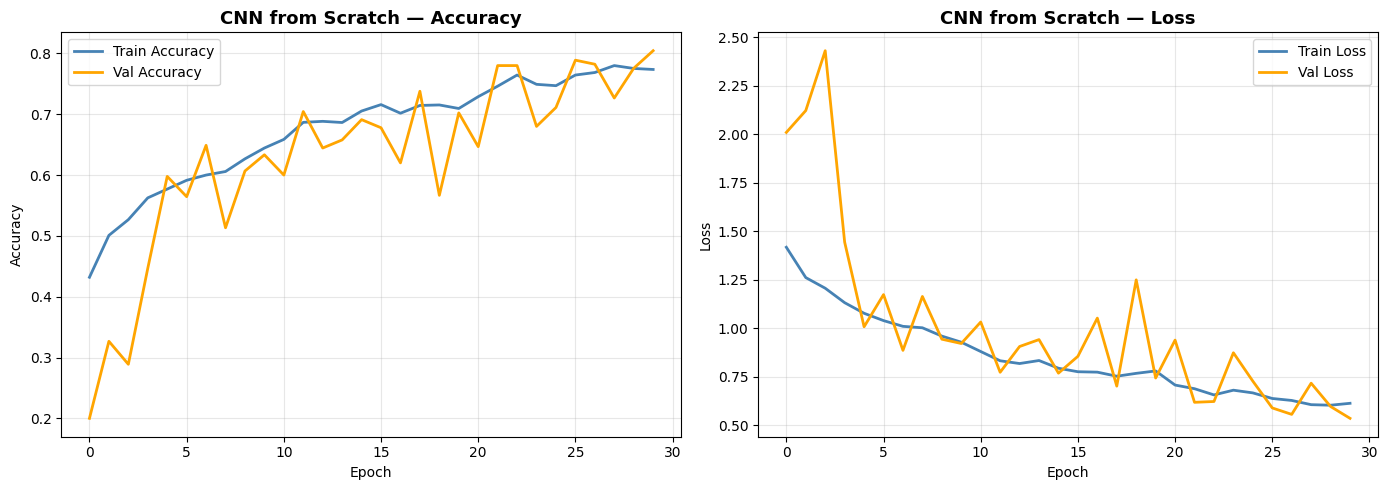

  Training curves saved → cnn_scratch_training_curves.png


EVALUATION — Test Set
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step

  Accuracy  : 0.8089  (80.89%)
  Precision : 0.8125
  Recall    : 0.8089
  F1-Score  : 0.8084

  Per-Class Classification Report:
              precision    recall  f1-score   support

     clothes       0.88      0.88      0.88        90
       glass       0.87      0.79      0.83        90
       metal       0.84      0.74      0.79        90
       paper       0.76      0.91      0.83        90
     plastic       0.72      0.72      0.72        90

    accuracy                           0.81       450
   macro avg       0.81      0.81      0.81       450
weighted avg       0.81      0.81      0.81       450



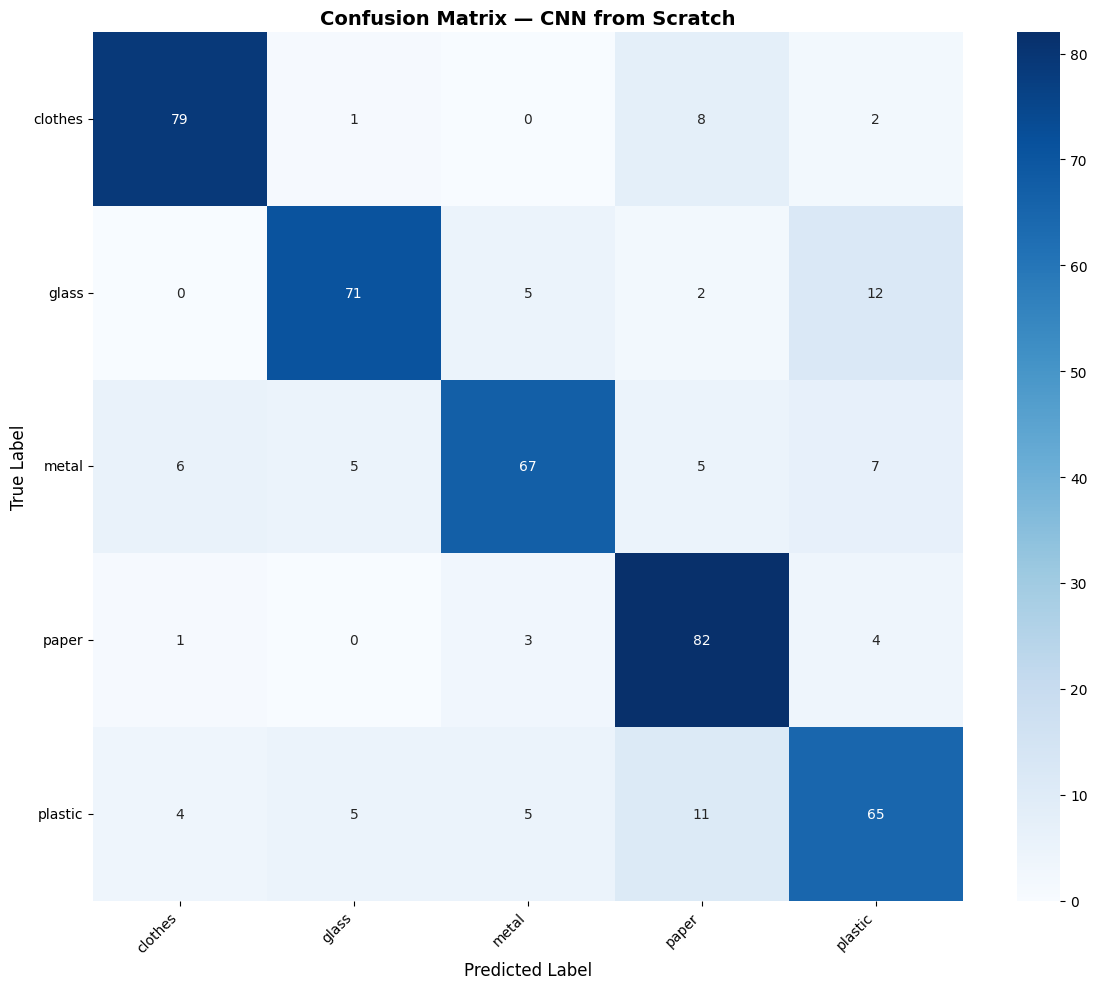

  Confusion matrix saved → cnn_scratch_confusion_matrix.png


FINAL RESULTS SUMMARY — CNN from Scratch
  Training Time : 4138.4s (69.0 min)
  Test Accuracy : 0.8089  (80.89%)
  Precision     : 0.8125
  Recall        : 0.8089
  F1-Score      : 0.8084

✅ CNN from Scratch — Complete.



In [20]:
# ============================================================
# MAIN — Full Pipeline
# ============================================================

if __name__ == "__main__":

    # ── IMPORT preprocessing_final to get data generators ──
    # Assumes preprocessing_final.py is in the same folder
    import sys
    sys.path.append(".")
    DATASET_PATH = "D:/ImgProject/filtered_dataset"
    print("\n" + "=" * 55)
    print("  GARBAGE CLASSIFICATION — CNN from Scratch")
    print("=" * 55 + "\n")

    # 1. Load data
    print("Loading data generators...")
    train_data, val_data, test_data = build_data_generators(DATASET_PATH)

    # 2. Build model
    print("\nBuilding CNN from scratch...")
    model = build_cnn_from_scratch()
    model = compile_model(model)

    # 3. Print architecture
    print_model_info(model)

    # 4. Train
    history, training_time = train_cnn(model, train_data, val_data, epochs=EPOCHS)

    # 5. Plot training curves
    plot_training_history(history, model_name="CNN from Scratch")

    # 6. Evaluate on test set
    results = evaluate_model(model, test_data)

    # 7. Save final results summary
    print("\n" + "=" * 55)
    print("FINAL RESULTS SUMMARY — CNN from Scratch")
    print("=" * 55)
    print(f"  Training Time : {training_time:.1f}s ({training_time/60:.1f} min)")
    print(f"  Test Accuracy : {results['accuracy']:.4f}  ({results['accuracy']*100:.2f}%)")
    print(f"  Precision     : {results['precision']:.4f}")
    print(f"  Recall        : {results['recall']:.4f}")
    print(f"  F1-Score      : {results['f1_score']:.4f}")
    print("=" * 55)
    print("\n✅ CNN from Scratch — Complete.\n")

    # Save results for comparison table (used later with Transfer Learning)
    cnn_scratch_results = {
        "model"         : "CNN from Scratch",
        "accuracy"      : results['accuracy'],
        "precision"     : results['precision'],
        "recall"        : results['recall'],
        "f1_score"      : results['f1_score'],
        "training_time" : training_time,
        "history"       : history
    }